In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
NUM_SEEDS = 20

METHODS = ['les_250_8','mes',  'logei', 'turbo','hci_gibo_09','sobol'] #'grad', 'nograd', 'gibo',
LABEL_NAMES = {'les_250_8':'LES (ours)',
'mes':'MES',
'turbo':'TuRBO',
'sobol':'Sobol random', 
'logei':'logEI',
'hci_gibo':'HCI-GIBO',
'hci_gibo_09':'HCI-GIBO'}


CUM_REGRET = True

In [10]:
def decompress_gibo(df):
    data = df[['y','n']].to_numpy(dtype=float)
    repeats = np.diff(data[:,-1].astype(int))
    repeats = np.insert(repeats, 0, data[0,-1])
    repeated = np.repeat(data[:, :-1], repeats, axis=0)
    return np.minimum.accumulate(repeated)

In [ ]:
DIMS = {'square': [5,30],
        'dixonprice': [5, 30],
        'ackley': [5, 30],
        'lunar_noise': [12],
        'lunar': [12],
        'rover': [200],
        'rover_trajectory': [60],
        'mopta08':[124]}

experiment_data = {}

## Import analytic functions ## 
for experiment in ['square', 'dixonprice', 'ackley', 'rover_trajectory', 'lunar','mopta08']: # ackley
    BEST_HIST_PATH = f"./Data/other_functions_non_informative_no_noise/{experiment}/optimizer_history/list_of_bests_"
    SAMPLED_POINTS_PATH = f"./Data/other_functions_non_informative_no_noise/{experiment}/sampled_data/sampled_data_history_"
    name = "no_noise"

    if CUM_REGRET:
        path = SAMPLED_POINTS_PATH
    else:
        path = BEST_HIST_PATH  


    avrg_best_history = []
    std_best_history = []
    lower_quantiles_history = []
    upper_quantiles_history = []

    for dim in DIMS[experiment]: 
        data_mean = []
        stds = []
        lower_quantile = []
        upper_quantile = []
        data_mean_normalized = []
        stds_normalized = []
        num_opjective_calls = min(20*dim, 400)
        if experiment == 'rover':
            num_opjective_calls = min(20*dim, 300)
        for method in range(len(METHODS)):
            y_data = np.zeros((0,0))
            for seed in range(NUM_SEEDS):
                file_identifier = f'{(seed+1):05d}_{dim}_{METHODS[method]}.csv'
                try: 
                    table = pd.read_csv(path + file_identifier) 
                except: 
                    print(f'Unable to find file {path+file_identifier}.')
                    continue

                if 'gibo' in METHODS[method] and not CUM_REGRET:
                    new_data = decompress_gibo(table.dropna())
                else:
                    new_data = np.reshape(table['y'].to_numpy(), [-1,1])

                if CUM_REGRET:
                    if y_data.shape[0] == 0:
                        y_data = np.expand_dims(np.cumsum(new_data[:num_opjective_calls, :]),axis = 1)
                    else: 
                        new_data = np.expand_dims(np.cumsum(new_data[:num_opjective_calls, :]),axis = 1)
                        y_data = np.concatenate([y_data, new_data], axis=1)
                else:
                    if y_data.shape[0] == 0:
                        y_data = new_data[:num_opjective_calls, :]
                    else: 
                        new_data = new_data[:num_opjective_calls, :]
                        y_data = np.concatenate([y_data, new_data], axis=1)

            data_mean.append(np.median(y_data, axis=1))
            stds.append(np.std(y_data, axis=1))
            lower_quantile.append(np.quantile(y_data, 0.25, axis=1))
            upper_quantile.append(np.quantile(y_data, 0.75, axis=1))

        avrg_best_history.append(data_mean)
        std_best_history.append(stds)
        lower_quantiles_history.append(lower_quantile)
        upper_quantiles_history.append(upper_quantile)
    experiment_data[experiment] = {'avrg': avrg_best_history,
                                   'std' : std_best_history,
                                   'lower' : lower_quantiles_history,
                                   'upper' : upper_quantiles_history}
    

Unable to find file ./Data/other_functions_non_informative_no_noise/square/sampled_data/sampled_data_history_00011_5_les_250_8.csv.
Unable to find file ./Data/other_functions_non_informative_no_noise/square/sampled_data/sampled_data_history_00012_5_les_250_8.csv.
Unable to find file ./Data/other_functions_non_informative_no_noise/square/sampled_data/sampled_data_history_00013_5_les_250_8.csv.
Unable to find file ./Data/other_functions_non_informative_no_noise/square/sampled_data/sampled_data_history_00014_5_les_250_8.csv.
Unable to find file ./Data/other_functions_non_informative_no_noise/square/sampled_data/sampled_data_history_00015_5_les_250_8.csv.
Unable to find file ./Data/other_functions_non_informative_no_noise/square/sampled_data/sampled_data_history_00016_5_les_250_8.csv.
Unable to find file ./Data/other_functions_non_informative_no_noise/square/sampled_data/sampled_data_history_00017_5_les_250_8.csv.
Unable to find file ./Data/other_functions_non_informative_no_noise/square/s

In [ ]:
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator, LinearLocator
from matplotlib.lines import Line2D

# Change font to Computer Modern
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # LaTeX default is Computer Modern
    "font.serif": ["Computer Modern Roman"],
    "axes.unicode_minus": False  # to handle minus signs correctly
})



colors =anonymized


width = 397.48 /72.27 # pt to in

In [13]:
if not CUM_REGRET:

    aspect_ratio = 0.25
    fontsize = 8
    linewidth = 0.8
    fig, axs = plt.subplots(1,4, figsize=(width,width*aspect_ratio))

    #############################
    ### SQUARE                ###
    #############################
    experiment = 'square'
    indices = [0]
    avrg_best_history = experiment_data[experiment]['avrg']
    upper_quantiles_history = experiment_data[experiment]['upper']
    lower_quantiles_history = experiment_data[experiment]['lower']


    for dim, index in enumerate(indices):
        dim=dim+1
        ax = axs.flat[index]

        all_y_values = []

        for method in range(len(METHODS)):
            all_y_values.append(avrg_best_history[dim][method])
            all_y_values.append(upper_quantiles_history[dim][method])
            all_y_values.append(lower_quantiles_history[dim][method])

        # Flatten and stack all y-data for this subplot
        all_y_values = np.concatenate([y.flatten() for y in all_y_values])
        y_min, y_max = all_y_values.min(), all_y_values.max()
        y_range = y_max - y_min if y_max != y_min else 1  # avoid divide by zero

        for method in range(len(METHODS)):
            # Normalize line
            y_line = avrg_best_history[dim][method]
            y_line_norm = (y_line - y_min) / y_range
            ax.plot(y_line_norm, color=colors[method], linestyle='-', linewidth=linewidth, zorder=len(METHODS)-method+1)

            # Normalize fill-between area
            x = np.arange(1, upper_quantiles_history[dim][method].shape[0]+1)
            y_upper = (upper_quantiles_history[dim][method] - y_min) / y_range
            y_lower = (lower_quantiles_history[dim][method] - y_min) / y_range
            ax.fill_between(x, y_upper, y_lower, color=colors[method], alpha=0.2)
        
        ax.set_xlabel('')
        ax.set_title(fr'Square: $d = {DIMS[experiment][dim]}$', fontsize=fontsize)
        ax.set_xlim(0, len(avrg_best_history[dim][0]))
        ax.set_ylim(-0.05,1)
        
        #ax.yaxis.set_major_locator(MaxNLocator(nbins=2))  # Adjust number of x-axis gridlines
        ax.set_yticks([0.0, 0.5, 1.0])
        ax.xaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))  # Adjust number of y-axis gridlines
        ax.yaxis.set_minor_locator(MaxNLocator(nbins=5))
        ax.set_xticks([0,np.ceil(len(avrg_best_history[dim][0])/100)*50,np.ceil(len(avrg_best_history[dim][0])/100)*100])

        #ax.minorticks_on()
        ax.tick_params(axis='both', which='both', size=0)
        ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7) 
        ax.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.7) 
        ax.tick_params(axis='both', which='major', labelsize=fontsize)

        for spine in ax.spines.values():
            spine.set_zorder(100)

    #fig.text(0.19, 0.9, "Square", ha='center', va='center', fontsize=fontsize+1)

    #############################
    ### Ackley                ###
    #############################
    experiment = 'ackley'#'ackley'
    indices = [1] #1
    avrg_best_history = experiment_data[experiment]['avrg']
    upper_quantiles_history = experiment_data[experiment]['upper']
    lower_quantiles_history = experiment_data[experiment]['lower']


    for dim, index in enumerate(indices):
        dim=dim+1
        dim = 1
        ax = axs.flat[index]
        all_y_values = []

        for method in range(len(METHODS)):
            all_y_values.append(avrg_best_history[dim][method])
            all_y_values.append(upper_quantiles_history[dim][method])
            all_y_values.append(lower_quantiles_history[dim][method])

        # Flatten and stack all y-data for this subplot
        all_y_values = np.concatenate([y.flatten() for y in all_y_values])
        y_min, y_max = all_y_values.min(), all_y_values.max()
        y_range = y_max - y_min if y_max != y_min else 1  # avoid divide by zero

        for method in range(len(METHODS)):
            # Normalize line
            y_line = avrg_best_history[dim][method]
            y_line_norm = (y_line - y_min) / y_range
            ax.plot(y_line_norm, color=colors[method], linestyle='-', linewidth=linewidth, zorder=len(METHODS)-method+1)

            # Normalize fill-between area
            x = np.arange(1, upper_quantiles_history[dim][method].shape[0]+1)
            y_upper = (upper_quantiles_history[dim][method] - y_min) / y_range
            y_lower = (lower_quantiles_history[dim][method] - y_min) / y_range
            ax.fill_between(x, y_upper, y_lower, color=colors[method], alpha=0.2)
        
        ax.set_xlabel('')
        ax.set_title(fr'Ackley: $d = {DIMS[experiment][dim]}$', fontsize=fontsize)
        ax.set_xlim(0, len(avrg_best_history[dim][0]))
        ax.set_ylim(-0.05,1)
        ax.set_yticklabels([])
        
        ax.set_yticks([0.0, 0.5, 1.0])
        ax.xaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))  # Adjust number of y-axis gridlines
        ax.yaxis.set_minor_locator(MaxNLocator(nbins=5))
        ax.set_xticks([0,np.ceil(len(avrg_best_history[dim][0])/100)*50,np.ceil(len(avrg_best_history[dim][0])/100)*100])

        #ax.minorticks_on()
        ax.tick_params(axis='both', which='both', size=0)
        ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7) 
        ax.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.7) 
        ax.tick_params(axis='both', which='major', labelsize=fontsize)

        for spine in ax.spines.values():
            spine.set_zorder(100)

    #fig.text(0.41, 0.9, "Ackley", ha='center', va='center', fontsize=fontsize+1) 

    #############################
    ### Lunar                ###
    #############################
    experiment = 'rover_trajectory'
    indices = [2]
    avrg_best_history = experiment_data[experiment]['avrg']
    upper_quantiles_history = experiment_data[experiment]['upper']
    lower_quantiles_history = experiment_data[experiment]['lower']


    for dim, index in enumerate(indices):
        ax = axs.flat[index]
        all_y_values = []

        for method in range(len(METHODS)):
            all_y_values.append(avrg_best_history[dim][method])
            all_y_values.append(upper_quantiles_history[dim][method])
            all_y_values.append(lower_quantiles_history[dim][method])

        # Flatten and stack all y-data for this subplot
        all_y_values = np.concatenate([y.flatten() for y in all_y_values])
        y_min, y_max = all_y_values.min(), all_y_values.max()
        y_range = y_max - y_min if y_max != y_min else 1  # avoid divide by zero

        for method in range(len(METHODS)):
            # Normalize line
            y_line = avrg_best_history[dim][method]
            y_line_norm = (y_line - y_min) / y_range
            ax.plot(y_line_norm, color=colors[method], linestyle='-', linewidth=linewidth, zorder=len(METHODS)-method+1)

            # Normalize fill-between area
            x = np.arange(1, upper_quantiles_history[dim][method].shape[0]+1)
            y_upper = (upper_quantiles_history[dim][method] - y_min) / y_range
            y_lower = (lower_quantiles_history[dim][method] - y_min) / y_range
            ax.fill_between(x, y_upper, y_lower, color=colors[method], alpha=0.2)
        
        ax.set_xlabel('')
        ax.set_title(fr'Rover: $d = {DIMS[experiment][dim]}$', fontsize=fontsize)
        ax.set_xlim(0, 240)
        ax.set_ylim(-0.05,1)
        
        #ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust number of x-axis gridlines
        ax.set_yticks([0.0, 0.5, 1.0])
        ax.xaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))  # Adjust number of y-axis gridlines
        ax.yaxis.set_minor_locator(MaxNLocator(nbins=5))
        ax.set_xticks([0,120,240])
        ax.set_yticklabels([])

        #ax.minorticks_on()
        ax.tick_params(axis='both', which='both', size=0)
        ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7) 
        ax.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.7) 
        ax.tick_params(axis='both', which='major', labelsize=fontsize)
        ax.yaxis.get_offset_text().set_fontsize(fontsize-2)

        for spine in ax.spines.values():
            spine.set_zorder(100)

    #fig.text(0.643, 0.9, "Lunar", ha='center', va='center', fontsize=fontsize+1) 


    #############################
    ### Rover                ###
    #############################
    experiment = 'mopta08'
    indices = [3]
    avrg_best_history = experiment_data[experiment]['avrg']
    upper_quantiles_history = experiment_data[experiment]['upper']
    lower_quantiles_history = experiment_data[experiment]['lower']


    for dim, index in enumerate(indices):
        ax = axs.flat[index]
        all_y_values = []

        for method in range(len(METHODS)):
            all_y_values.append(avrg_best_history[dim][method])
            all_y_values.append(upper_quantiles_history[dim][method])
            all_y_values.append(lower_quantiles_history[dim][method])

        # Flatten and stack all y-data for this subplot
        all_y_values = np.concatenate([y.flatten() for y in all_y_values])
        y_min, y_max = all_y_values.min(), all_y_values.max()
        y_range = y_max - y_min if y_max != y_min else 1  # avoid divide by zero

        for method in range(len(METHODS)):
            # Normalize line
            y_line = avrg_best_history[dim][method]
            y_line_norm = (y_line - y_min) / y_range
            ax.plot(y_line_norm, color=colors[method], linestyle='-', linewidth=linewidth, zorder=len(METHODS)-method+1)

            # Normalize fill-between area
            x = np.arange(1, upper_quantiles_history[dim][method].shape[0]+1)
            y_upper = (upper_quantiles_history[dim][method] - y_min) / y_range
            y_lower = (lower_quantiles_history[dim][method] - y_min) / y_range
            ax.fill_between(x, y_upper, y_lower, color=colors[method], alpha=0.2)
        
        ax.set_xlabel('')
        ax.set_title(fr'Mopta08: $d = {DIMS[experiment][dim]}$', fontsize=fontsize)
        ax.set_xlim(0, len(avrg_best_history[dim][1]))
        ax.set_ylim(-0.05, 1)
        

        ax.xaxis.set_minor_locator(MaxNLocator(nbins=4))  
        ax.yaxis.set_minor_locator(MaxNLocator(nbins=5))
        ax.set_xticks([0,np.ceil(len(avrg_best_history[dim][1])/100)*50,np.ceil(len(avrg_best_history[dim][1])/100)*100])
        ax.set_yticks([0.0, 0.5, 1.0])
        ax.set_yticklabels([])

        #ax.minorticks_on()
        ax.tick_params(axis='both', which='both', size=0)
        ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7) 
        ax.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.7) 
        ax.tick_params(axis='both', which='major', labelsize=fontsize)
        #ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax.yaxis.get_offset_text().set_fontsize(fontsize-2)

        for spine in ax.spines.values():
            spine.set_zorder(100)

    #fig.text(0.864, 0.9, "Rover", ha='center', va='center', fontsize=fontsize+1)


    #############################
    ### GENERAL               ###
    #############################

    #axs[0][0].set_yticks([x for x in range(-10,1,2)])
    #axs.flat[0].set_yticks(np.linspace(0, -2, 3))
    axs.flat[0].set_ylabel(r'$\overline{f}(\hat{\mathbf{x}}^*)$', fontsize=fontsize)
    fig.text(0.5, 0.01, r'Evaluations \#', ha='center', fontsize=fontsize)
    legend_elements = [Line2D([0], [0], color=colors[i], lw=linewidth*1.2, linestyle='-', label=LABEL_NAMES[METHODS[i]]) for i in range(len(METHODS))]

    fig.tight_layout(rect=[0, 0, 1, 0.93], h_pad=1.)  # adjust layout to leave space below
    fig.legend(
        handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.3),
        ncol=3,
        fontsize=fontsize,
        frameon=False,
    )
    plt.subplots_adjust(wspace=0.15)
    fig.savefig(name + "analytic_comparisons_short.pdf", bbox_inches='tight', pad_inches=0.0)

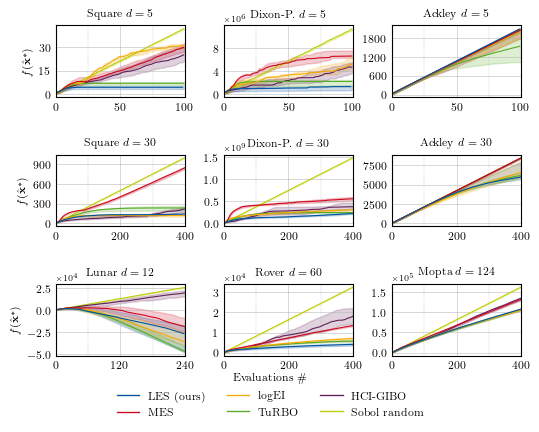

In [14]:
aspect_ratio = 0.45
fontsize = 8
linewidth = 0.8

LAYOUT_3by3 = True

if LAYOUT_3by3:
    fig, axs = plt.subplots(3,3, figsize=(width,width*aspect_ratio*1.7))
else:
    fig, axs = plt.subplots(2,4, figsize=(width,width*aspect_ratio))

#############################
### SQUARE                ###
#############################
experiment = 'square'
if LAYOUT_3by3:
    indices = [0,3]
else:
    indices = [0,4]
avrg_best_history = experiment_data[experiment]['avrg']
upper_quantiles_history = experiment_data[experiment]['upper']
lower_quantiles_history = experiment_data[experiment]['lower']


for dim, index in enumerate(indices):
    ax = axs.flat[index]
    for method in range(len(METHODS)):
        ax.plot(avrg_best_history[dim][method], color=colors[method], linestyle='-', linewidth=linewidth, zorder=len(METHODS)-method+1)
        x = np.arange(1, upper_quantiles_history[dim][method].shape[0]+1)
        ax.fill_between(x, upper_quantiles_history[dim][method], lower_quantiles_history[dim][method], 
                           color=colors[method], alpha=0.2)
    
    ax.set_xlabel('')
    ax.set_title(fr'Square $d = {DIMS[experiment][dim]}$', fontsize=fontsize)
    ax.set_xlim(0, len(avrg_best_history[dim][0]))
    
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust number of x-axis gridlines
    ax.xaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))  # Adjust number of y-axis gridlines
    #ax.yaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))
    ax.set_xticks([0,np.ceil(len(avrg_best_history[dim][0])/100)*50,np.ceil(len(avrg_best_history[dim][0])/100)*100])

    #ax.minorticks_on()
    ax.tick_params(axis='both', which='both', size=0)
    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7) 
    ax.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.7) 
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

    for spine in ax.spines.values():
        spine.set_zorder(100)

#fig.text(0.195, 0.92, "Square", ha='center', va='center', fontsize=fontsize+1)

#############################
### DIXONPRICE            ###
#############################
experiment = 'dixonprice'
if LAYOUT_3by3:
    indices = [1,4]
else:
    indices = [1,5]
avrg_best_history = experiment_data[experiment]['avrg']
upper_quantiles_history = experiment_data[experiment]['upper']
lower_quantiles_history = experiment_data[experiment]['lower']


for dim, index in enumerate(indices):
    ax = axs.flat[index]
    for method in range(len(METHODS)):
        ax.plot(avrg_best_history[dim][method], color=colors[method], linestyle='-', linewidth=linewidth, zorder=len(METHODS)-method+1)
        x = np.arange(1, upper_quantiles_history[dim][method].shape[0]+1)
        ax.fill_between(x, upper_quantiles_history[dim][method], lower_quantiles_history[dim][method], 
                           color=colors[method], alpha=0.2)
    
    ax.set_xlabel('')
    ax.set_title(fr'Dixon-P. $d = {DIMS[experiment][dim]}$', fontsize=fontsize)
    ax.set_xlim(0, len(avrg_best_history[dim][0]))
    
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust number of x-axis gridlines
    ax.xaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))  # Adjust number of y-axis gridlines
    #ax.yaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))
    ax.set_xticks([0,np.ceil(len(avrg_best_history[dim][0])/100)*50,np.ceil(len(avrg_best_history[dim][0])/100)*100])

    #ax.minorticks_on()
    ax.tick_params(axis='both', which='both', size=0)
    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7) 
    ax.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.7) 

    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.yaxis.get_offset_text().set_fontsize(fontsize-2)

    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    for spine in ax.spines.values():
        spine.set_zorder(100)

#fig.text(0.42, 0.92, "Dixon-Price", ha='center', va='center', fontsize=fontsize+1)

#############################
### Ackley                ###
#############################
experiment = 'ackley'
if LAYOUT_3by3:
    indices = [2,5]
else:
    indices = [2,6]
avrg_best_history = experiment_data[experiment]['avrg']
upper_quantiles_history = experiment_data[experiment]['upper']
lower_quantiles_history = experiment_data[experiment]['lower']


for dim, index in enumerate(indices):
    ax = axs.flat[index]
    for method in range(len(METHODS)):
        ax.plot(avrg_best_history[dim][method], color=colors[method], linestyle='-', linewidth=linewidth, zorder=len(METHODS)-method+1)
        x = np.arange(1, upper_quantiles_history[dim][method].shape[0]+1)
        ax.fill_between(x, upper_quantiles_history[dim][method], lower_quantiles_history[dim][method], 
                           color=colors[method], alpha=0.2)
    
    ax.set_xlabel('')
    ax.set_title(fr'Ackley $d = {DIMS[experiment][dim]}$', fontsize=fontsize)
    ax.set_xlim(0, len(avrg_best_history[dim][0]))
    
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust number of x-axis gridlines
    ax.xaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))  # Adjust number of y-axis gridlines
    #ax.yaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))
    ax.set_xticks([0,np.ceil(len(avrg_best_history[dim][0])/100)*50,np.ceil(len(avrg_best_history[dim][0])/100)*100])

    #ax.minorticks_on()
    ax.tick_params(axis='both', which='both', size=0)
    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7) 
    ax.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.7) 
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

    for spine in ax.spines.values():
        spine.set_zorder(100)

#fig.text(0.643, 0.92, "Ackley", ha='center', va='center', fontsize=fontsize+1)

#############################
### Lunar                ###
#############################
experiment = 'lunar'
indices = [6]
avrg_best_history = experiment_data[experiment]['avrg']
upper_quantiles_history = experiment_data[experiment]['upper']
lower_quantiles_history = experiment_data[experiment]['lower']


for dim, index in enumerate(indices):
    ax = axs.flat[index]
    for method in range(len(METHODS)):
        ax.plot(avrg_best_history[dim][method], color=colors[method], linestyle='-', linewidth=linewidth, zorder=len(METHODS)-method+1)
        x = np.arange(1, upper_quantiles_history[dim][method].shape[0]+1)
        ax.fill_between(x, upper_quantiles_history[dim][method], lower_quantiles_history[dim][method], 
                           color=colors[method], alpha=0.2)
    
    ax.set_xlabel('')
    ax.set_title(fr'Lunar $d = {DIMS[experiment][dim]}$', fontsize=fontsize)
    ax.set_xlim(0, 240)
    
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust number of x-axis gridlines
    ax.xaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))  # Adjust number of y-axis gridlines
    #ax.yaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))
    ax.set_xticks([0,120,240])

    #ax.minorticks_on()
    ax.tick_params(axis='both', which='both', size=0)
    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7) 
    ax.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.7) 
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.get_offset_text().set_fontsize(fontsize-2)

    for spine in ax.spines.values():
        spine.set_zorder(100)

#fig.text(0.87, 0.92, "Lunar", ha='center', va='center', fontsize=fontsize+1)


#############################
### Rover                ###
#############################
experiment = 'rover_trajectory'
indices = [7]
avrg_best_history = experiment_data[experiment]['avrg']
upper_quantiles_history = experiment_data[experiment]['upper']
lower_quantiles_history = experiment_data[experiment]['lower']


for dim, index in enumerate(indices):
    ax = axs.flat[index]
    for method in range(len(METHODS)):
        ax.plot(avrg_best_history[dim][method], color=colors[method], linestyle='-', linewidth=linewidth, zorder=len(METHODS)-method+1)
        x = np.arange(1, upper_quantiles_history[dim][method].shape[0]+1)
        ax.fill_between(x, upper_quantiles_history[dim][method], lower_quantiles_history[dim][method], 
                           color=colors[method], alpha=0.2)
    
    ax.set_xlabel('')
    ax.set_title(fr'Rover $d = {DIMS[experiment][dim]}$', fontsize=fontsize)
    ax.set_xlim(0, len(avrg_best_history[dim][1]))
    
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust number of x-axis gridlines
    ax.xaxis.set_minor_locator(MaxNLocator(nbins=4))  # Adjust number of y-axis gridlines
    #ax.yaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))
    ax.set_xticks([0,np.ceil(len(avrg_best_history[dim][1])/100)*50,np.ceil(len(avrg_best_history[dim][1])/100)*100])

    #ax.minorticks_on()
    ax.tick_params(axis='both', which='both', size=0)
    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7) 
    ax.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.7) 
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.get_offset_text().set_fontsize(fontsize-2)

    for spine in ax.spines.values():
        spine.set_zorder(100)

#fig.text(0.87, 0.45, "Rover", ha='center', va='center', fontsize=fontsize+1)


experiment = 'mopta08'
indices = [8]
avrg_best_history = experiment_data[experiment]['avrg']
upper_quantiles_history = experiment_data[experiment]['upper']
lower_quantiles_history = experiment_data[experiment]['lower']


for dim, index in enumerate(indices):
    ax = axs.flat[index]
    for method in range(len(METHODS)):
        ax.plot(avrg_best_history[dim][method], color=colors[method], linestyle='-', linewidth=linewidth, zorder=len(METHODS)-method+1)
        x = np.arange(1, upper_quantiles_history[dim][method].shape[0]+1)
        ax.fill_between(x, upper_quantiles_history[dim][method], lower_quantiles_history[dim][method], 
                           color=colors[method], alpha=0.2)
    
    ax.set_xlabel('')
    ax.set_title(fr'Mopta $d = {DIMS[experiment][dim]}$', fontsize=fontsize)
    ax.set_xlim(0, len(avrg_best_history[dim][1]))
    
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust number of x-axis gridlines
    ax.xaxis.set_minor_locator(MaxNLocator(nbins=4))  # Adjust number of y-axis gridlines
    #ax.yaxis.set_minor_locator(MaxNLocator(integer=True, nbins=4))
    ax.set_xticks([0,np.ceil(len(avrg_best_history[dim][1])/100)*50,np.ceil(len(avrg_best_history[dim][1])/100)*100])

    #ax.minorticks_on()
    ax.tick_params(axis='both', which='both', size=0)
    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7) 
    ax.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.7) 
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.get_offset_text().set_fontsize(fontsize-2)

    for spine in ax.spines.values():
        spine.set_zorder(100)

#fig.text(0.87, 0.45, "Mopta08", ha='center', va='center', fontsize=fontsize+1)


#############################
### GENERAL               ###
#############################

#axs[0][0].set_yticks([x for x in range(-10,1,2)])
#axs.flat[0].set_yticks(np.linspace(0, -2, 3))
if LAYOUT_3by3:
    axs.flat[0].set_ylabel(r'$f(\hat{\mathbf{x}}^*)$', fontsize=fontsize)
    axs.flat[3].set_ylabel(r'$f(\hat{\mathbf{x}}^*)$', fontsize=fontsize)
    axs.flat[6].set_ylabel(r'$f(\hat{\mathbf{x}}^*)$', fontsize=fontsize)
else:
    axs.flat[0].set_ylabel(r'$f(\hat{\mathbf{x}}^*)$', fontsize=fontsize)
    axs.flat[4].set_ylabel(r'$f(\hat{\mathbf{x}}^*)$', fontsize=fontsize)
fig.text(0.5, 0.01, r'Evaluations \#', ha='center', fontsize=fontsize)
legend_elements = [Line2D([0], [0], color=colors[i], lw=linewidth*1.2, linestyle='-', label=LABEL_NAMES[METHODS[i]]) for i in range(len(METHODS))]

#fig.tight_layout(rect=[0, 0, 1, 0.93], h_pad=1.8)  # adjust layout to leave space below
fig.tight_layout(rect=[0, 0, 1, 0.93])  # adjust layout to leave space below
fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    fontsize=fontsize,
    frameon=False,
)
plt.subplots_adjust(wspace=0.3)
if CUM_REGRET:
    fig.savefig(name + "analytic_comparisons_cum.pdf", bbox_inches='tight', pad_inches=0.0)
else:
    fig.savefig(name + "analytic_comparisons.pdf", bbox_inches='tight', pad_inches=0.0)